<center>
    <div>
        <h1>Task 3</h1>
        <br>
        <h2>Simple Linear Regression with Gradient Descent.</h2>
    </div>
</center>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("car_price_prediction_task3_dataset.csv")

In [4]:
df.head()

,car_id,year,brand,engine_cc,mileage_kmpl,kilometers_driven,fuel_type,transmission,owner_count,service_history_score,insurance_valid_years,accident_history_count,selling_price
0,1,2021,Toyota,2200,14.4,86820,Petrol,Manual,3,7,3,0,928000
1,2,2018,Honda,2200,24.6,72955,Diesel,Manual,1,5,3,1,759000
2,3,2020,Tata,1800,12.3,116970,Petrol,Manual,3,10,1,2,591000
3,4,2017,Toyota,1800,19.7,21394,Diesel,Manual,1,6,3,0,867000
4,5,2016,Hyundai,1000,12.2,33483,Petrol,Manual,3,7,1,0,457000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   car_id                  120 non-null    int64  
 1   year                    120 non-null    int64  
 2   brand                   120 non-null    object 
 3   engine_cc               120 non-null    int64  
 4   mileage_kmpl            120 non-null    float64
 5   kilometers_driven       120 non-null    int64  
 6   fuel_type               120 non-null    object 
 7   transmission            120 non-null    object 
 8   owner_count             120 non-null    int64  
 9   service_history_score   120 non-null    int64  
 10  insurance_valid_years   120 non-null    int64  
 11  accident_history_count  120 non-null    int64  
 12  selling_price           120 non-null    int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 12.3+ KB


In [6]:
df.describe()

,car_id,year,engine_cc,mileage_kmpl,kilometers_driven,owner_count,service_history_score,insurance_valid_years,accident_history_count,selling_price
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,1.200000e+02
mean,60.500000,2019.241667,1535.833333,18.344167,66986.508333,1.908333,7.491667,1.508333,0.941667,7.183083e+05
std,34.785054,2.771390,436.909666,3.854361,33019.108344,0.869616,1.810315,1.144925,0.812671,2.315679e+05
min,1.000000,2015.000000,1000.000000,12.100000,10854.000000,1.000000,5.000000,0.000000,0.000000,2.310000e+05
25%,30.750000,2017.000000,1200.000000,14.900000,41939.750000,1.000000,6.000000,1.000000,0.000000,5.342500e+05
50%,60.500000,2019.000000,1500.000000,18.350000,63223.500000,2.000000,7.000000,1.000000,1.000000,6.980000e+05
75%,90.250000,2022.000000,1800.000000,21.225000,95295.500000,3.000000,9.000000,3.000000,2.000000,9.060000e+05
max,120.000000,2024.000000,2200.000000,25.000000,119751.000000,3.000000,10.000000,3.000000,2.000000,1.319000e+06


In [7]:
# features that affect car price the most:
# X = features, y = target

X = df[[
    "year",
    "engine_cc",
    "mileage_kmpl",
    "kilometers_driven",
    "owner_count",
    "service_history_score",
    "insurance_valid_years",
    "accident_history_count"
]]

y = df["selling_price"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(96, 8)
(24, 8)


In [10]:
model = LinearRegression()

In [11]:
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred = model.predict(X_test_scaled)

In [13]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred.round(0)
})

comparison.head(10)

,Actual Price,Predicted Price
0,428000,430245.0
1,689000,682237.0
2,457000,482112.0
3,1319000,1248765.0
4,756000,718728.0
5,397000,397302.0
6,395000,411558.0
7,548000,478963.0
8,565000,601888.0
9,825000,847600.0


In [14]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", round(mse, 2))
print("R² Score:", round(r2, 4))

Mean Squared Error: 3227129609.67
R² Score: 0.9444


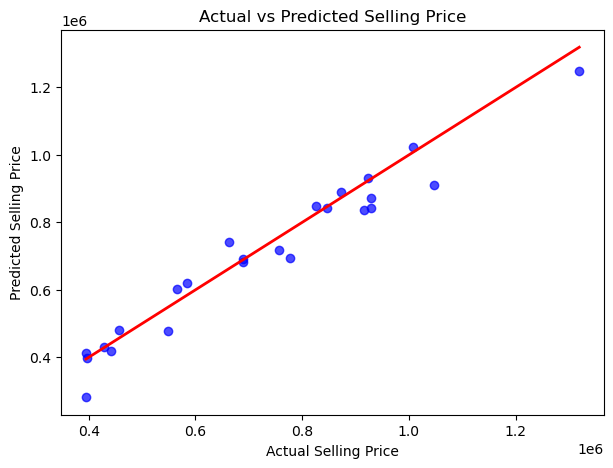

In [15]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred, color="blue", alpha=0.7)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

In [16]:
y_train_np = y_train.values
y_test_np = y_test.values

In [17]:
weights = np.zeros(X_train_scaled.shape[1])
bias = 0

learning_rate = 0.01
epochs = 1000

In [18]:
n = len(X_train_scaled)
loss_history = []

for i in range(epochs):

    # Prediction
    y_pred = np.dot(X_train_scaled, weights) + bias

    # Error
    error = y_pred - y_train_np

    # Loss (MSE)
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # Gradients
    dw = (2/n) * np.dot(X_train_scaled.T, error)
    db = (2/n) * np.sum(error)

    # Update parameters
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

    # Print progress every 200 epochs
    if i % 200 == 0:
        print(f"Epoch {i}: Loss = {loss:.2f}")

Epoch 0: Loss = 565583427083.33
Epoch 200: Loss = 1867059423.52
Epoch 400: Loss = 1682488314.72
Epoch 600: Loss = 1682351385.32
Epoch 800: Loss = 1682350969.72


In [19]:
print("Final Weights:\n")

for feature, w in zip(X.columns, weights):
    print(f"{feature}: {w:.4f}")

print("\nFinal Bias:", round(bias, 4))

Final Weights:

year: 177793.7400
engine_cc: 45135.4862
mileage_kmpl: 15112.9372
kilometers_driven: -77588.1687
owner_count: -30690.0243
service_history_score: 21798.9117
insurance_valid_years: 17448.0832
accident_history_count: -24302.8592

Final Bias: 716677.0821


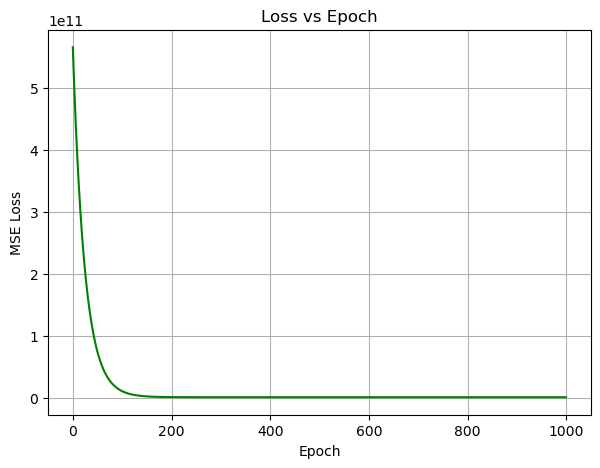

In [20]:
plt.figure(figsize=(7,5))
plt.plot(loss_history, color="green")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss vs Epoch")
plt.grid(True)
plt.show()

In [24]:
y_pred_gd = np.dot(X_test_scaled, weights) + bias

In [25]:
from sklearn.metrics import mean_squared_error, r2_score

In [26]:
mse_gd = mean_squared_error(y_test_np, y_pred_gd)
r2_gd = r2_score(y_test_np, y_pred_gd)

print("Gradient Descent MSE:", round(mse_gd, 2))
print("Gradient Descent R² :", round(r2_gd, 4))

Gradient Descent MSE: 3227131136.88
Gradient Descent R² : 0.9444


In [28]:
y_pred = model.predict(X_test_scaled)
print("Sklearn R²:", round(r2_score(y_test, y_pred), 4))
print("Manual  R²:", round(r2_gd, 4))

Sklearn R²: 0.9444
Manual  R²: 0.9444
